In [55]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

data_passenger = pd.read_csv('../Titanic-Dataset.csv')

In [56]:
# Load the two Titanic datasets
train = pd.read_csv("../train.csv")
test = pd.read_csv("../test.csv")

# Mark which dataset each row came from
train["is_train"] = 1
test["is_train"] = 0

# Combine them temporarily for preprocessing
combined = pd.concat([train, test], ignore_index=True)

# Fill missing values
combined["Age"] = combined["Age"].fillna(combined["Age"].median())
combined["Fare"] = combined["Fare"].fillna(combined["Fare"].median())
combined["Embarked"] = combined["Embarked"].fillna(
    combined["Embarked"].mode()[0]
)

# Convert Sex into numbers
combined["Sex"] = combined["Sex"].map({
    "male": 0,
    "female": 1
})

# Convert Embarked into numerical columns
combined = pd.get_dummies(
    combined,
    columns=["Embarked"],
    drop_first=True
)

# Separate the data again
train_processed = combined[combined["is_train"] == 1].copy()
test_processed = combined[combined["is_train"] == 0].copy()

# Check that everything worked
print("Train shape:", train_processed.shape)
print("Test shape:", test_processed.shape)

Train shape: (891, 14)
Test shape: (418, 14)


In [57]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S"
]

X = train_processed[features]
y = train_processed["Survived"]
X_test = test_processed[features]

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 8)
y: (891,)
X_test: (418, 8)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (712, 8)
X_valid: (179, 8)
y_train: (712,)
y_valid: (179,)


In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

In [60]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [61]:
y_pred = model.predict(X_valid)

In [62]:
print(y_pred[:20])

[0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print("Validation accuracy:", accuracy)

Validation accuracy: 0.8044692737430168


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.92      0.85       110
         1.0       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print("Validation accuracy:", accuracy)

Validation accuracy: 0.8044692737430168


Making improvements

In [66]:
# combined["Title"] = combined["Name"].str.extract(
#     r",\s*([^.]*)\."
# )[0]

In [67]:
def get_title(name):
    parts = name.split(",")
    title_part = parts[1]
    title = title_part.split(".")[0]
    return title.strip()

In [68]:
combined["Title"] = combined["Name"].apply(get_title)

In [69]:
print(combined["Title"].value_counts())

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


In [70]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

combined["Title"] = combined["Title"].where(
    combined["Title"].isin(common_titles),
    "Rare"
)

In [71]:
print(combined["Title"].value_counts())

Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [72]:
combined = pd.get_dummies(
    combined,
    columns=["Title"],
    drop_first=True
)

In [73]:
print(combined.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'is_train', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [74]:
combined["FamilySize"] = (
    combined["SibSp"] +
    combined["Parch"] +
    1
)

In [75]:
combined["IsAlone"] = (
    combined["FamilySize"] == 1
).astype(int)

In [76]:
train_processed = combined[
    combined["is_train"] == 1
].copy()

test_processed = combined[
    combined["is_train"] == 0
].copy()

In [77]:
print("Train:", train_processed.shape)
print("Test:", test_processed.shape)

Train: (891, 20)
Test: (418, 20)


In [78]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S",
    "FamilySize",
    "IsAlone",
    "Title_Miss",
    "Title_Mr",
    "Title_Mrs",
    "Title_Rare"
]

In [79]:
X = train_processed[features]

y = train_processed["Survived"]

X_test = test_processed[features]

In [80]:
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 14)
y: (891,)
X_test: (418, 14)


In [81]:
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 14)
y: (891,)
X_test: (418, 14)


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (712, 14)
Validation: (179, 14)


In [83]:
from sklearn.ensemble import RandomForestClassifier

model_improved = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

In [84]:
model_improved.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [85]:
y_pred_improved = model_improved.predict(X_valid)

In [86]:
from sklearn.metrics import accuracy_score

accuracy_improved = accuracy_score(
    y_valid,
    y_pred_improved
)

print("Improved validation accuracy:", accuracy_improved)

Improved validation accuracy: 0.8268156424581006


In [87]:
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [88]:
test_predictions = final_model.predict(X_test)

In [89]:
print(len(test_predictions))

418


In [90]:
print(test_predictions[:20])

[0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]


In [91]:
print(set(test_predictions))

{np.float64(0.0), np.float64(1.0)}


In [92]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions.astype(int)
})

In [93]:
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [94]:
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Missing values:")
print(submission.isnull().sum())

Shape: (418, 2)
Columns: ['PassengerId', 'Survived']
Missing values:
PassengerId    0
Survived       0
dtype: int64


In [95]:
print(submission["Survived"].value_counts())

Survived
0    267
1    151
Name: count, dtype: int64


In [96]:
submission.to_csv("submission.csv", index=False)

In [97]:
import os

print(os.path.exists("submission.csv"))

True


In [98]:
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print(submission.isnull().sum())

Shape: (418, 2)
Columns: ['PassengerId', 'Survived']
PassengerId    0
Survived       0
dtype: int64


In [99]:
submission.to_csv("submission.csv", index=False)

In [100]:
import os

print(os.path.exists("submission.csv"))

True


Now for the visuals

In [101]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Processed train:", train_processed.shape)
print("Processed test:", test_processed.shape)

Train: (891, 13)
Test: (418, 12)
Processed train: (891, 20)
Processed test: (418, 20)


In [102]:
import pandas as pd

train = pd.read_csv("../train.csv")
test = pd.read_csv("../test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (891, 12)
Test: (418, 11)


In [103]:
total_passengers = len(train)

survivors = train["Survived"].sum()

survival_rate = train["Survived"].mean() * 100

print("Total passengers:", total_passengers)
print("Survivors:", survivors)
print("Survival rate:", round(survival_rate, 2), "%")

Total passengers: 891
Survivors: 342
Survival rate: 38.38 %


In [104]:
total_passengers = len(train)

survivors = train["Survived"].sum()

survival_rate = train["Survived"].mean() * 100

print("Total passengers:", total_passengers)
print("Survivors:", survivors)
print("Survival rate:", round(survival_rate, 2), "%")

Total passengers: 891
Survivors: 342
Survival rate: 38.38 %


In [105]:
train["Survived"].mean()

np.float64(0.3838383838383838)

In [106]:
gender_survival = (
    train.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


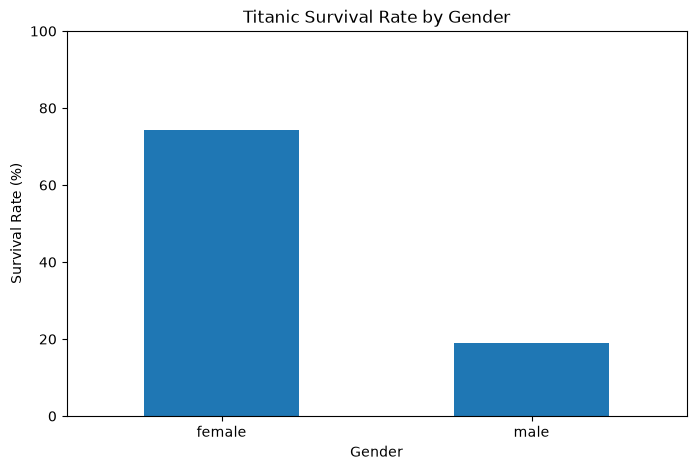

In [107]:
gender_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Titanic Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

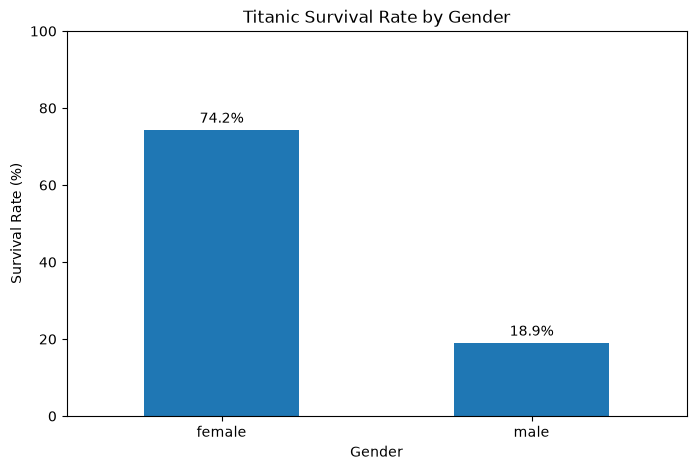

In [108]:
ax = gender_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Titanic Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(gender_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../train.csv")

print(train.shape)

(891, 12)


In [110]:
total_passengers = len(train)

survivors = train["Survived"].sum()

survival_rate = train["Survived"].mean() * 100

print("Total passengers:", total_passengers)
print("Survivors:", survivors)
print("Survival rate:", round(survival_rate, 2), "%")

Total passengers: 891
Survivors: 342
Survival rate: 38.38 %


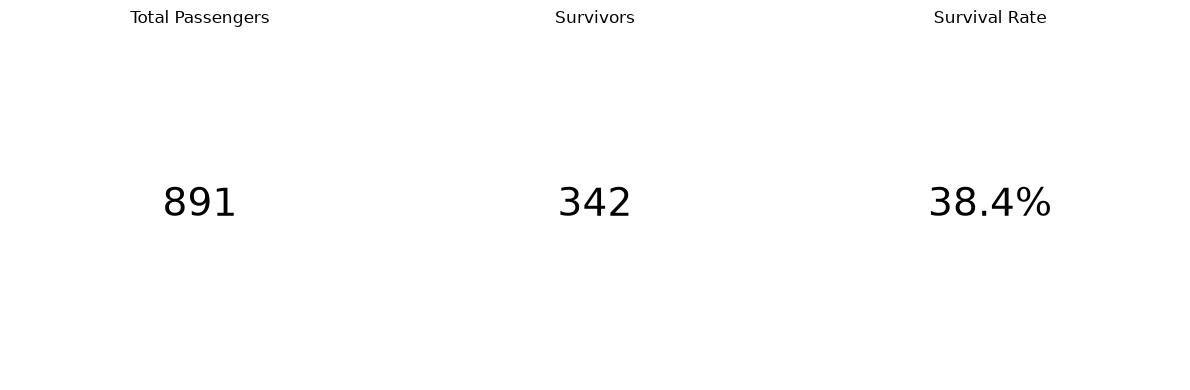

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Card 1
axes[0].text(
    0.5, 0.5,
    f"{total_passengers}",
    ha="center",
    va="center",
    fontsize=28
)
axes[0].set_title("Total Passengers")
axes[0].axis("off")

# Card 2
axes[1].text(
    0.5, 0.5,
    f"{survivors}",
    ha="center",
    va="center",
    fontsize=28
)
axes[1].set_title("Survivors")
axes[1].axis("off")

# Card 3
axes[2].text(
    0.5, 0.5,
    f"{survival_rate:.1f}%",
    ha="center",
    va="center",
    fontsize=28
)
axes[2].set_title("Survival Rate")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [112]:
gender_survival = (
    train.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


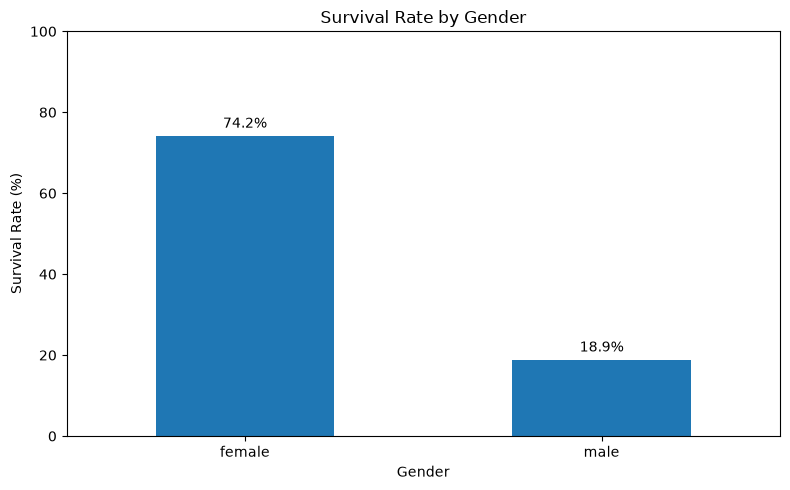

In [113]:
ax = gender_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(gender_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

Gender was strongly associated with survival. Approximately three-quarters of female passengers survived, compared with fewer than one-fifth of male passengers.

In [114]:
class_survival = (
    train.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
)

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


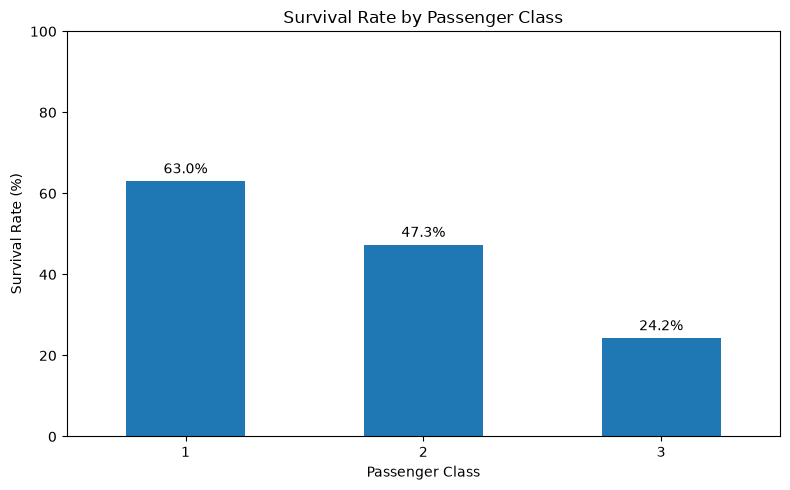

In [115]:
ax = class_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(class_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

Passenger class was also strongly associated with survival. First-class passengers had a survival rate of approximately 63%, compared with only 24.2% among third-class passengers.

In [116]:
print(train["Age"].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


In [117]:
bins = [0, 12, 17, 29, 49, 100]

labels = [
    "Child",
    "Teenager",
    "Young Adult",
    "Adult",
    "Senior"
]

train["AgeGroup"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels
)

In [118]:
age_survival = (
    train.groupby("AgeGroup", observed=True)["Survived"]
    .mean()
    .mul(100)
)

print(age_survival)

AgeGroup
Child          57.971014
Teenager       47.727273
Young Adult    35.055351
Adult          41.796875
Senior         36.486486
Name: Survived, dtype: float64


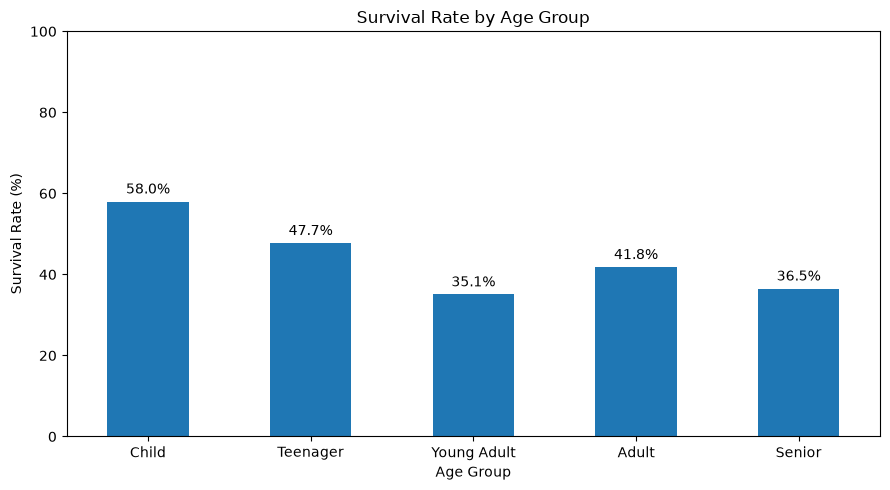

In [119]:
ax = age_survival.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(age_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

Survival varied across age groups, with younger passengers showing different survival patterns from adults and seniors. However, age alone does not explain survival as strongly as gender or passenger class.

In [120]:
train["FamilySize"] = (
    train["SibSp"] +
    train["Parch"] +
    1
)

print(train[["SibSp", "Parch", "FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [121]:
print(train["FamilySize"].value_counts().sort_index())

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [122]:
def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small family"
    elif size <= 6:
        return "Medium family"
    else:
        return "Large family"

train["FamilyGroup"] = train["FamilySize"].apply(family_group)

In [123]:
family_survival = (
    train.groupby("FamilyGroup")["Survived"]
    .mean()
    .mul(100)
)

print(family_survival)

FamilyGroup
Alone            30.353818
Large family     16.000000
Medium family    16.216216
Small family     57.876712
Name: Survived, dtype: float64


In [124]:
family_order = [
    "Alone",
    "Small family",
    "Medium family",
    "Large family"
]

family_survival = family_survival.reindex(family_order)

print(family_survival)

FamilyGroup
Alone            30.353818
Small family     57.876712
Medium family    16.216216
Large family     16.000000
Name: Survived, dtype: float64


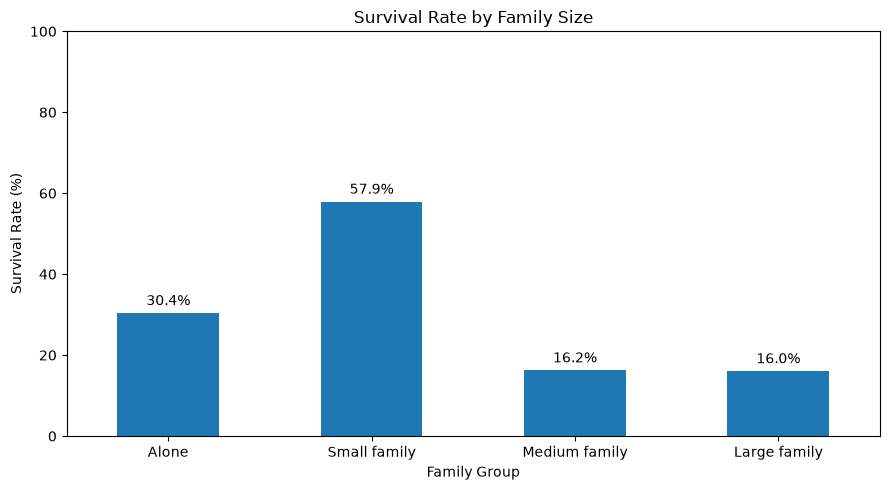

In [125]:
ax = family_survival.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(family_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

Survival varied by family size, with passengers traveling in small family groups generally showing more favorable survival rates than those traveling alone or in very large groups

In [126]:
print("final_model" in globals())

True


In [127]:
import pandas as pd

train = pd.read_csv("../train.csv")
test = pd.read_csv("../test.csv")

print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [128]:
combined = pd.concat(
    [train.drop("Survived", axis=1), test],
    ignore_index=True
)

combined["is_train"] = [
    1 if i < len(train) else 0
    for i in range(len(combined))
]

print(combined.shape)

(1309, 12)


In [129]:
def get_title(name):
    parts = name.split(",")
    title_part = parts[1]
    title = title_part.split(".")[0]
    return title.strip()

combined["Title"] = combined["Name"].apply(get_title)

In [130]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

combined["Title"] = combined["Title"].where(
    combined["Title"].isin(common_titles),
    "Rare"
)

In [131]:
combined["FamilySize"] = (
    combined["SibSp"] +
    combined["Parch"] +
    1
)

combined["IsAlone"] = (
    combined["FamilySize"] == 1
).astype(int)

In [132]:
combined["Sex"] = combined["Sex"].map({
    "male": 0,
    "female": 1
})

In [133]:
combined["Embarked"] = combined["Embarked"].fillna(
    combined["Embarked"].mode()[0]
)

In [134]:
combined = pd.get_dummies(
    combined,
    columns=["Embarked", "Title"],
    drop_first=True
)

In [135]:
combined["Age"] = combined["Age"].fillna(
    combined["Age"].median()
)

combined["Fare"] = combined["Fare"].fillna(
    combined["Fare"].median()
)

In [136]:
train_processed = combined[
    combined["is_train"] == 1
].copy()

test_processed = combined[
    combined["is_train"] == 0
].copy()

In [137]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S",
    "FamilySize",
    "IsAlone",
    "Title_Miss",
    "Title_Mr",
    "Title_Mrs",
    "Title_Rare"
]

X = train_processed[features]

y = train["Survived"]

X_test = test_processed[features]

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 14)
y: (891,)
X_test: (418, 14)


In [138]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

In [139]:
final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [140]:
importance = pd.Series(
    final_model.feature_importances_,
    index=features
)

importance = importance.sort_values(
    ascending=False
)

print(importance)

Sex           0.205633
Title_Mr      0.197481
Fare          0.142545
Pclass        0.103454
Age           0.086368
FamilySize    0.058569
Title_Mrs     0.054026
Title_Miss    0.053233
SibSp         0.035548
Parch         0.019750
Embarked_S    0.017373
IsAlone       0.010680
Embarked_Q    0.007870
Title_Rare    0.007471
dtype: float64


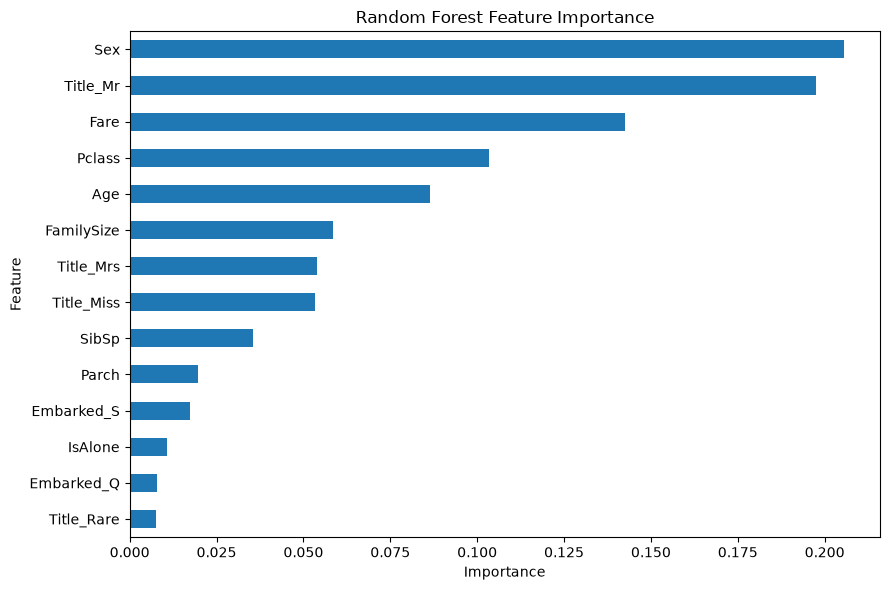

In [141]:
plt.figure(figsize=(9, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [142]:
print(importance)

Sex           0.205633
Title_Mr      0.197481
Fare          0.142545
Pclass        0.103454
Age           0.086368
FamilySize    0.058569
Title_Mrs     0.054026
Title_Miss    0.053233
SibSp         0.035548
Parch         0.019750
Embarked_S    0.017373
IsAlone       0.010680
Embarked_Q    0.007870
Title_Rare    0.007471
dtype: float64


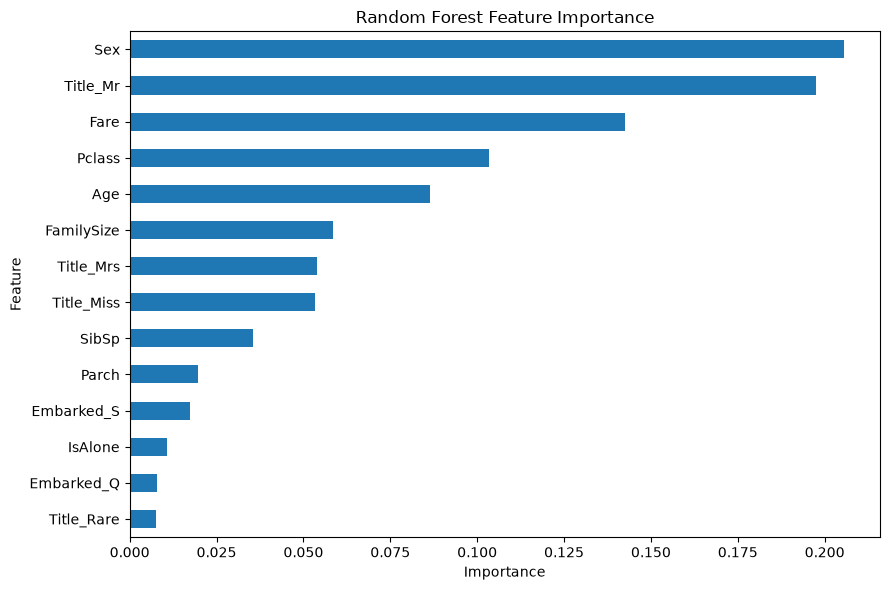

In [143]:
plt.figure(figsize=(9, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

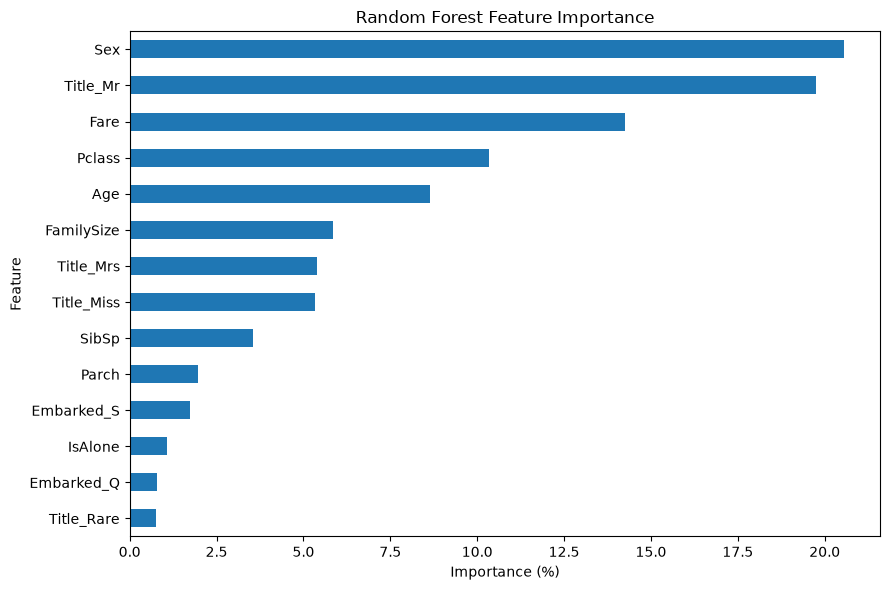

In [144]:
importance_percent = importance * 100

plt.figure(figsize=(9, 6))

importance_percent.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The Random Forest relied most heavily on gender, passenger title, fare, and passenger class when predicting survival. This aligns with the exploratory analysis, where gender and socioeconomic class showed strong differences in survival rates.

Sex was the most influential feature in this Random Forest model.

In [145]:
original_accuracy = 0.8044692737430168
improved_accuracy = 0.8268156424581006

print("Original model:", round(original_accuracy * 100, 2), "%")
print("Improved model:", round(improved_accuracy * 100, 2), "%")

Original model: 80.45 %
Improved model: 82.68 %


In [146]:
improvement = (
    improved_accuracy - original_accuracy
) * 100

print("Improvement:", round(improvement, 2), "percentage points")

Improvement: 2.23 percentage points


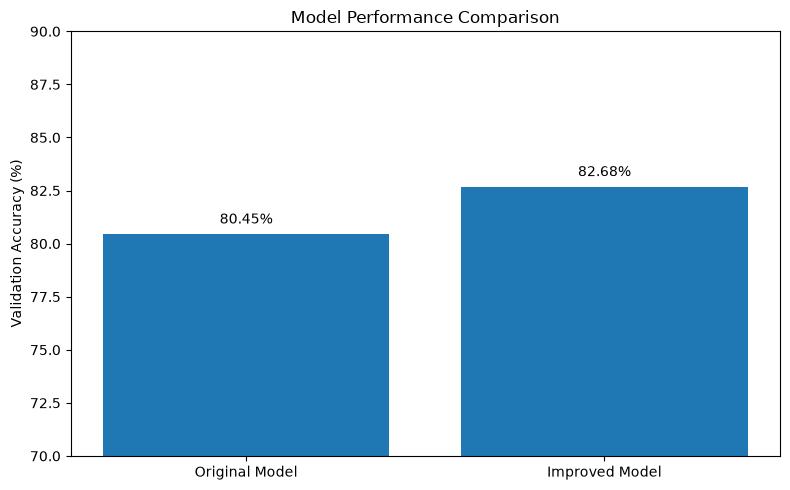

In [147]:
model_names = [
    "Original Model",
    "Improved Model"
]

model_scores = [
    original_accuracy * 100,
    improved_accuracy * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    model_scores
)

plt.title("Model Performance Comparison")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(70, 90)

for bar, score in zip(bars, model_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.5,
        f"{score:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

The engineered-feature model improved validation accuracy from 80.45% to 82.68%, an increase of 2.23 percentage points on the selected validation split.

Question 1

How many passengers survived?

→ KPI cards

Question 2

Did gender matter?

→ Gender chart

Question 3

Did passenger class matter?

→ Class chart

Question 4

Did age matter?

→ Age chart

Question 5

Did family size matter?

→ Family-size chart

Question 6

What information did our ML model find useful?

→ Feature importance

Question 7

Did our feature engineering improve the model?

→ Model comparison

That's a complete analytical story.

In [148]:
bins = [0, 12, 17, 29, 49, 100]

labels = [
    "Child",
    "Teenager",
    "Young Adult",
    "Adult",
    "Senior"
]

train["AgeGroup"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels
)

In [149]:
train["FamilySize"] = (
    train["SibSp"] +
    train["Parch"] +
    1
)


def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small family"
    elif size <= 6:
        return "Medium family"
    else:
        return "Large family"


train["FamilyGroup"] = train["FamilySize"].apply(family_group)

In [150]:
print(train[["AgeGroup", "FamilySize", "FamilyGroup"]].head())

      AgeGroup  FamilySize   FamilyGroup
0  Young Adult           2  Small family
1        Adult           2  Small family
2  Young Adult           1         Alone
3        Adult           2  Small family
4        Adult           1         Alone


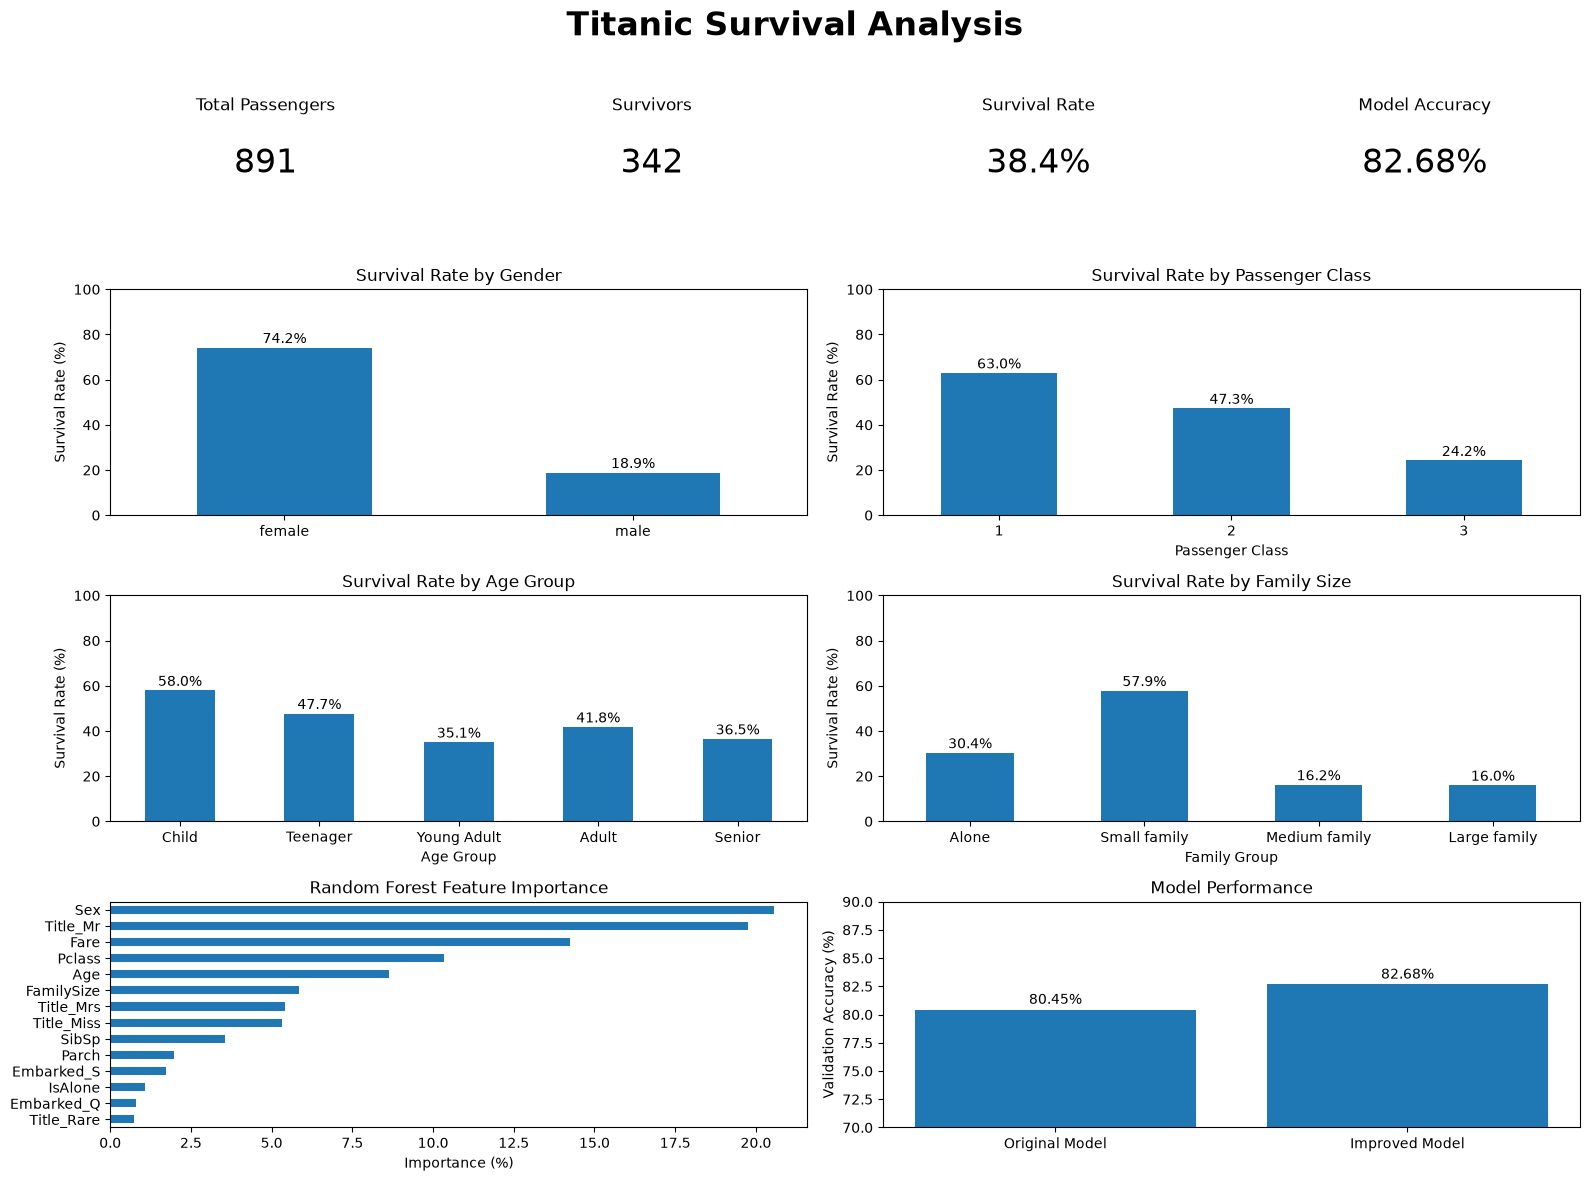

In [151]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Calculate dashboard data
# -----------------------------

# KPIs
total_passengers = len(train)
survivors = train["Survived"].sum()
survival_rate = train["Survived"].mean() * 100

# Gender
gender_survival = (
    train.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

# Passenger class
class_survival = (
    train.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
)

# Age
age_survival = (
    train.groupby("AgeGroup", observed=True)["Survived"]
    .mean()
    .mul(100)
)

# Family
family_survival = (
    train.groupby("FamilyGroup")["Survived"]
    .mean()
    .mul(100)
)

family_order = [
    "Alone",
    "Small family",
    "Medium family",
    "Large family"
]

family_survival = family_survival.reindex(family_order)

# Feature importance
importance_percent = importance * 100

# Model performance
model_names = [
    "Original Model",
    "Improved Model"
]

model_scores = [
    original_accuracy * 100,
    improved_accuracy * 100
]


# -----------------------------
# 2. Create dashboard layout
# -----------------------------

fig = plt.figure(figsize=(16, 12))

gs = fig.add_gridspec(
    4,
    4,
    height_ratios=[1, 2.5, 2.5, 2.5]
)

fig.suptitle(
    "Titanic Survival Analysis",
    fontsize=24,
    fontweight="bold"
)


# -----------------------------
# 3. KPI cards
# -----------------------------

kpi1 = fig.add_subplot(gs[0, 0])
kpi2 = fig.add_subplot(gs[0, 1])
kpi3 = fig.add_subplot(gs[0, 2])
kpi4 = fig.add_subplot(gs[0, 3])

kpi1.text(
    0.5, 0.5,
    f"{total_passengers}",
    ha="center",
    va="center",
    fontsize=24
)
kpi1.set_title("Total Passengers")
kpi1.axis("off")

kpi2.text(
    0.5, 0.5,
    f"{survivors}",
    ha="center",
    va="center",
    fontsize=24
)
kpi2.set_title("Survivors")
kpi2.axis("off")

kpi3.text(
    0.5, 0.5,
    f"{survival_rate:.1f}%",
    ha="center",
    va="center",
    fontsize=24
)
kpi3.set_title("Survival Rate")
kpi3.axis("off")

kpi4.text(
    0.5, 0.5,
    f"{improved_accuracy * 100:.2f}%",
    ha="center",
    va="center",
    fontsize=24
)
kpi4.set_title("Model Accuracy")
kpi4.axis("off")


# -----------------------------
# 4. Gender chart
# -----------------------------

ax1 = fig.add_subplot(gs[1, 0:2])

gender_survival.plot(
    kind="bar",
    ax=ax1
)

ax1.set_title("Survival Rate by Gender")
ax1.set_xlabel("")
ax1.set_ylabel("Survival Rate (%)")
ax1.set_ylim(0, 100)
ax1.tick_params(axis="x", rotation=0)

for i, value in enumerate(gender_survival):
    ax1.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )


# -----------------------------
# 5. Class chart
# -----------------------------

ax2 = fig.add_subplot(gs[1, 2:4])

class_survival.plot(
    kind="bar",
    ax=ax2
)

ax2.set_title("Survival Rate by Passenger Class")
ax2.set_xlabel("Passenger Class")
ax2.set_ylabel("Survival Rate (%)")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="x", rotation=0)

for i, value in enumerate(class_survival):
    ax2.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )


# -----------------------------
# 6. Age chart
# -----------------------------

ax3 = fig.add_subplot(gs[2, 0:2])

age_survival.plot(
    kind="bar",
    ax=ax3
)

ax3.set_title("Survival Rate by Age Group")
ax3.set_xlabel("Age Group")
ax3.set_ylabel("Survival Rate (%)")
ax3.set_ylim(0, 100)
ax3.tick_params(axis="x", rotation=0)

for i, value in enumerate(age_survival):
    ax3.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )


# -----------------------------
# 7. Family chart
# -----------------------------

ax4 = fig.add_subplot(gs[2, 2:4])

family_survival.plot(
    kind="bar",
    ax=ax4
)

ax4.set_title("Survival Rate by Family Size")
ax4.set_xlabel("Family Group")
ax4.set_ylabel("Survival Rate (%)")
ax4.set_ylim(0, 100)
ax4.tick_params(axis="x", rotation=0)

for i, value in enumerate(family_survival):
    ax4.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )


# -----------------------------
# 8. Feature importance
# -----------------------------

ax5 = fig.add_subplot(gs[3, 0:2])

importance_percent.sort_values().plot(
    kind="barh",
    ax=ax5
)

ax5.set_title("Random Forest Feature Importance")
ax5.set_xlabel("Importance (%)")
ax5.set_ylabel("")


# -----------------------------
# 9. Model comparison
# -----------------------------

ax6 = fig.add_subplot(gs[3, 2:4])

bars = ax6.bar(
    model_names,
    model_scores
)

ax6.set_title("Model Performance")
ax6.set_ylabel("Validation Accuracy (%)")
ax6.set_ylim(70, 90)

for bar, score in zip(bars, model_scores):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.5,
        f"{score:.2f}%",
        ha="center"
    )


# -----------------------------
# 10. Final layout
# -----------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

# Key Insights

### 1. Gender was strongly associated with survival
Female passengers had a substantially higher survival rate than male passengers.

### 2. Passenger class was strongly associated with survival
First-class passengers had a considerably higher survival rate than third-class passengers.

### 3. Age showed differences in survival
Survival varied across age groups, although the relationship was less straightforward than gender or passenger class.

### 4. Family size showed a non-linear relationship
Passengers traveling in small family groups generally had more favorable survival rates than passengers traveling alone or in very large families.

### 5. Important predictive features
The Random Forest model relied most heavily on Sex, Title_Mr, Fare, Pclass, and Age when making predictions.

### 6. Feature engineering improved model performance
Validation accuracy increased from 80.45% to 82.68% after adding engineered features such as Title, FamilySize, and IsAlone.

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [153]:
from sklearn.ensemble import RandomForestClassifier

eval_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

eval_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [154]:
y_pred = eval_model.predict(X_valid)

In [155]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Accuracy : 0.827
Precision: 0.817
Recall   : 0.71
F1 Score : 0.76


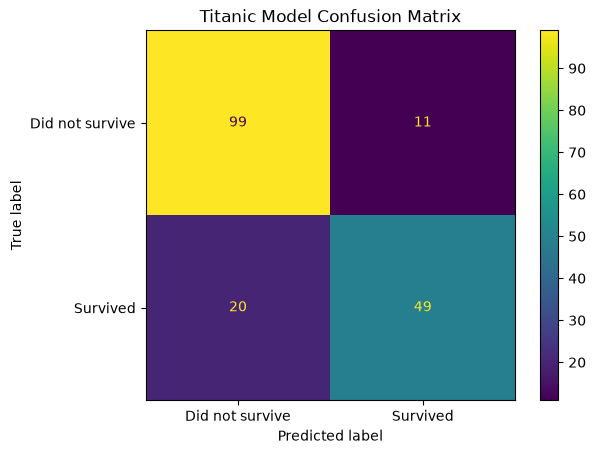

In [156]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
)

disp.plot()

plt.title("Titanic Model Confusion Matrix")
plt.show()